# 06 — XGBoost Régression : Prédiction du PnL par stratégie

**Objectif** : entraîner un modèle de régression XGBoost par stratégie (ASRS, Expresso, PDHL)
pour prédire le PnL attendu de chaque trade.

Un PnL prédit élevé → on prend le trade et on vise un TP dynamique basé sur la prédiction.  
Un PnL prédit faible/négatif → on filtre le trade.

| Stratégie | Signal bar | Buffer | Entrée après |
|-----------|-----------|--------|-------------|
| ASRS      | 09:15     | ±2 pts | 09:20       |
| Expresso  | 08:55     | ±17 pts| 09:00       |
| PDHL   | 08:50–09:00 (10min) | ±2 pts | 09:00 |

In [37]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error
import joblib

warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print(f'ROOT = {ROOT}')

ROOT = c:\Users\ali\Desktop\Projet-INFO-2AS2


## 1. Chargement des données

In [38]:
from pathlib import Path
import yfinance as yf
import pandas as pd

ext_path = ROOT / "data" / "ext_features.csv"

if not ext_path.exists():
    print("Téléchargement VIX / SPX / EUR/USD via yfinance...")
    tickers = {"vix": "^VIX", "spx": "^GSPC", "eurusd": "EURUSD=X"}
    frames = {}
    for name, ticker in tickers.items():
        df = yf.download(ticker, start="2005-01-01", progress=False)
        frames[name] = df["Close"].squeeze()
    ext_df = pd.DataFrame(frames)
    ext_df.index.name = "date"
    ext_df.to_csv(ext_path)
    print(f"Sauvegarde : {len(ext_df)} lignes -> {ext_path}")
else:
    print(f"ext_features.csv existe deja ({ext_path.stat().st_size//1024} KB)")


ext_features.csv existe deja (350 KB)


In [39]:

# ── Raw 5-min DAX data ────────────────────────────────────────────────────────
raw = pd.read_csv(
    ROOT / 'data' / 'dax-5m_bk.csv', sep=';', header=None,
    names=['date', 'time', 'open', 'high', 'low', 'close', 'volume'],
)
raw['datetime'] = pd.to_datetime(raw['date'] + ' ' + raw['time'], format='%d/%m/%Y %H:%M')
raw = raw.drop(columns=['date', 'time']).set_index('datetime').sort_index()
raw = raw[raw.index >= '2006-01-01']

# ── External features (VIX, SPX, EURUSD) ─────────────────────────────────────
ext_raw = pd.read_csv(ROOT / 'data' / 'ext_features.csv', index_col=0, parse_dates=True)
ext = ext_raw.copy()
ext['vix_prev']      = ext['vix'].shift(1)
ext['vix_5d_change'] = ext['vix'].shift(1) - ext['vix'].shift(6)
ext['spx_prev_ret']  = ext['spx'].pct_change().shift(1) * 100
ext.dropna(inplace=True)

print(f'Raw rows : {len(raw):,}  ({raw.index[0].date()} → {raw.index[-1].date()})')
print(f'Ext rows : {len(ext):,}  colonnes : {ext.columns.tolist()}')


Raw rows : 998,622  (2006-01-02 → 2026-04-06)
Ext rows : 4,760  colonnes : ['vix', 'spx', 'eurusd', 'vix_prev', 'vix_5d_change', 'spx_prev_ret']


## 2. Moteur de backtest avec max_favorable

In [40]:
RANGE_MIN, RANGE_MAX = 10, 55
SKIP_DOW    = [4]
SKIP_MONTHS = [1, 7, 8]

def simulate_full(day_bars, sig_high, sig_low, buffer):
    """Simule un trade OCO et retourne PnL + max_favorable."""
    if day_bars.empty:
        return None
    entry_long  = sig_high + buffer
    entry_short = sig_low  - buffer

    # Si le prix ouvre deja au-dela d un niveau -> skip (gap irréaliste)
    first_open = day_bars["open"].iloc[0]
    if first_open >= entry_long or first_open <= entry_short:
        return None
    stop_long   = entry_short
    stop_short  = entry_long
    direction = entry_price = entry_time = stop = None

    for ts, bar in day_bars.iterrows():
        if direction is not None: break
        bh, bl = bar['high'], bar['low']
        if bh >= entry_long and bl <= entry_short:
            if bar['open'] >= entry_long:
                direction, entry_price, stop = 'long', entry_long, stop_long
            else:
                direction, entry_price, stop = 'short', entry_short, stop_short
        elif bh >= entry_long:
            direction, entry_price, stop = 'long', entry_long, stop_long
        elif bl <= entry_short:
            direction, entry_price, stop = 'short', entry_short, stop_short
        if direction is not None:
            entry_time = ts

    if direction is None:
        return None

    max_favorable = 0.0
    max_adverse   = 0.0
    exit_price = None

    for ts, bar in day_bars[day_bars.index >= entry_time].iterrows():
        bh, bl = bar['high'], bar['low']
        if direction == 'long':
            max_favorable = max(max_favorable, bh - entry_price)
            max_adverse   = max(max_adverse,   entry_price - bl)
            if bl <= stop: exit_price = stop; break
        else:
            max_favorable = max(max_favorable, entry_price - bl)
            max_adverse   = max(max_adverse,   bh - entry_price)
            if bh >= stop: exit_price = stop; break

    if exit_price is None:
        exit_price = day_bars[day_bars.index >= entry_time].iloc[-1]['close']

    pnl = (exit_price - entry_price) if direction == 'long' else (entry_price - exit_price)
    return {
        'direction'    : direction,
        'entry_price'  : round(entry_price, 2),
        'pnl'          : round(pnl, 2),
        'max_favorable': round(max_favorable, 2),
        'max_adverse'  : round(max_adverse,   2),
        'initial_risk' : round(abs(entry_price - stop), 2),
        'sig_range'    : round(sig_high - sig_low, 2),
    }

print('simulate_full() défini.')

simulate_full() défini.


In [41]:
def run_strategy(bar_time, buffer, after_time, is_10min=False):
    """Lance le backtest avec filtres F1+F2+C4. Retourne DataFrame de trades."""
    if is_10min:
        b1 = raw[raw.index.strftime('%H:%M') == '08:50'].copy()
        b2 = raw[raw.index.strftime('%H:%M') == '08:55'].copy()
        b1['td'] = b1.index.date; b2['td'] = b2.index.date
        b1 = b1.set_index('td'); b2 = b2.set_index('td')
        common = b1.index.intersection(b2.index)
        bars_by_date = pd.DataFrame({
            'high' : pd.concat([b1['high'], b2['high']], axis=1).max(axis=1).loc[common],
            'low'  : pd.concat([b1['low'],  b2['low']],  axis=1).min(axis=1).loc[common],
        })
    else:
        bars = raw[raw.index.strftime('%H:%M') == bar_time].copy()
        bars['td'] = bars.index.date
        bars_by_date = bars.set_index('td')[['high', 'low']]

    bars_by_date['bar_range'] = bars_by_date['high'] - bars_by_date['low']
    bars_by_date = bars_by_date[(bars_by_date['bar_range'] > 0.1) & (bars_by_date['bar_range'] < 500)]

    trades = []
    for trade_date in bars_by_date.index.unique():
        ts_date = pd.Timestamp(trade_date)
        if ts_date.dayofweek in SKIP_DOW:   continue
        if ts_date.month    in SKIP_MONTHS: continue
        row = bars_by_date.loc[trade_date]
        if isinstance(row, pd.DataFrame): row = row.iloc[0]
        sig_high, sig_low = row['high'], row['low']
        if not (RANGE_MIN <= sig_high - sig_low <= RANGE_MAX): continue
        day_bars = raw.loc[
            pd.Timestamp(f'{trade_date} {after_time}'):
            pd.Timestamp(f'{trade_date} 17:35')
        ]
        if len(day_bars) < 2: continue
        r = simulate_full(day_bars, sig_high, sig_low, buffer)
        if r:
            r['trade_date'] = ts_date
            trades.append(r)

    df = pd.DataFrame(trades).set_index('trade_date').sort_index()
    print(f'  {len(df):,} trades  |  PnL total {df["pnl"].sum():+,.0f} pts  |  WR {(df["pnl"]>0).mean()*100:.1f}%')
    return df

print('Lancement des 3 backtests...')
print('ASRS :')
df_asrs = run_strategy('09:15', buffer=2,  after_time='09:20')
print('Expresso :')
df_exp  = run_strategy('08:55', buffer=17, after_time='09:00')
print('PDHL :')
df_pdhl = run_strategy(None,    buffer=2,  after_time='09:00', is_10min=True)

Lancement des 3 backtests...
ASRS :
  2,131 trades  |  PnL total +9,139 pts  |  WR 30.2%
Expresso :
  2,074 trades  |  PnL total +9,832 pts  |  WR 46.6%
PDHL :
  2,547 trades  |  PnL total +6,014 pts  |  WR 34.1%


In [42]:
def run_pdhl_strategy():
    """PDHL : signal = PDH/PDL de la veille, buffer = 5 pts, filtres F1+F3."""
    dates = sorted(set(raw.index.date))
    trades = []
    for i in range(1, len(dates)):
        today, yesterday = dates[i], dates[i-1]
        ts = pd.Timestamp(today)
        if ts.dayofweek in SKIP_DOW:   continue
        if ts.month    in SKIP_MONTHS: continue
        prev = raw.loc[str(yesterday)]
        curr = raw.loc[pd.Timestamp(f"{today} 09:00"):pd.Timestamp(f"{today} 17:35")]
        if len(prev) < 2 or len(curr) < 2: continue
        pdh, pdl = prev["high"].max(), prev["low"].min()
        if not (50 <= pdh - pdl <= 300): continue  # filtre range journalier
        r = simulate_full(curr, pdh, pdl, buffer=5)
        if r:
            r["trade_date"] = ts
            trades.append(r)
    df = pd.DataFrame(trades).set_index("trade_date").sort_index()
    print(f"  {len(df):,} trades  |  PnL total {df["pnl"].sum():+,.0f} pts  |  WR {(df["pnl"]>0).mean()*100:.1f}%")
    return df

print('PDHL (PDH/PDL) :')
df_pdhl = run_pdhl_strategy()


PDHL (PDH/PDL) :
  754 trades  |  PnL total +3,895 pts  |  WR 52.8%


## 3. Construction des features

In [43]:
def true_range(df):
    prev = df['close'].shift(1)
    return pd.concat([
        df['high'] - df['low'],
        (df['high'] - prev).abs(),
        (df['low']  - prev).abs(),
    ], axis=1).max(axis=1)

raw['tr'] = true_range(raw)

# Pré-calcul quotidien
daily = raw.groupby(raw.index.date).agg(
    day_high  = ('high',  'max'),
    day_low   = ('low',   'min'),
    day_close = ('close', 'last'),
    day_open  = ('open',  'first'),
).rename_axis('date')
daily.index = pd.to_datetime(daily.index)
daily['prev_close']     = daily['day_close'].shift(1)
daily['prev_range']     = (daily['day_high'] - daily['day_low']).shift(1)
daily['prev_day_ret']   = daily['day_close'].pct_change().shift(1) * 100
daily['prev_close_pos'] = (
    (daily['day_close'] - daily['day_low']) /
    (daily['day_high']  - daily['day_low'] + 1e-9)
).shift(1)

# ATR rolling
raw['atr14'] = raw['tr'].rolling(14, min_periods=1).mean()
raw['atr5']  = raw['tr'].rolling(5,  min_periods=1).mean()
atr_snap = raw.groupby(raw.index.date)[['atr14', 'atr5']].last()
atr_snap.index = pd.to_datetime(atr_snap.index)

# Signal bar features
def get_bar_features(bar_time):
    bars = raw[raw.index.strftime('%H:%M') == bar_time].copy()
    bars['td'] = pd.to_datetime(bars.index.date)
    bars = bars.set_index('td')
    r = bars['high'] - bars['low']
    d = r.replace(0, 1)
    bars['body']       = (bars['close'] - bars['open']).abs() / d
    bars['wick_upper'] = (bars['high'] - bars[['open','close']].max(axis=1)) / d
    bars['wick_lower'] = (bars[['open','close']].min(axis=1) - bars['low']) / d
    bars['bullish']    = (bars['close'] > bars['open']).astype(int)
    return bars[['body', 'wick_upper', 'wick_lower', 'bullish']]

def get_pdhl_bar_features():
    b1 = raw[raw.index.strftime('%H:%M') == '08:50'].copy()
    b2 = raw[raw.index.strftime('%H:%M') == '08:55'].copy()
    b1['td'] = pd.to_datetime(b1.index.date)
    b2['td'] = pd.to_datetime(b2.index.date)
    b1 = b1.set_index('td'); b2 = b2.set_index('td')
    common = b1.index.intersection(b2.index)
    sig_o = b1.loc[common, 'open']
    sig_h = pd.concat([b1['high'], b2['high']], axis=1).max(axis=1).loc[common]
    sig_l = pd.concat([b1['low'],  b2['low']],  axis=1).min(axis=1).loc[common]
    sig_c = b2.loc[common, 'close']
    r = sig_h - sig_l
    d = r.replace(0, 1)
    return pd.DataFrame({
        'body':       (sig_c - sig_o).abs() / d,
        'wick_upper': (sig_h - pd.concat([sig_o, sig_c], axis=1).max(axis=1)) / d,
        'wick_lower': (pd.concat([sig_o, sig_c], axis=1).min(axis=1) - sig_l) / d,
        'bullish':    (sig_c > sig_o).astype(int),
    })

# Gap 09:00
open_bars = raw[raw.index.strftime('%H:%M') == '09:00'].copy()
open_bars['td'] = pd.to_datetime(open_bars.index.date)
open_bars = open_bars.set_index('td')[['open']].rename(columns={'open': 'open_900'})

ext_daily = ext.copy()
ext_daily.index = pd.to_datetime(ext_daily.index).normalize()

def build_features_fast(trades_df, signal_bar_time=None, is_10min=False):
    td_idx = pd.to_datetime(trades_df.index).normalize()

    bar_feat = get_pdhl_bar_features() if is_10min else get_bar_features(signal_bar_time)

    feat = trades_df[['pnl', 'max_favorable', 'max_adverse', 'sig_range', 'initial_risk', 'direction']].copy()
    feat.index = td_idx
    feat['direction_enc'] = (feat['direction'] == 'long').astype(int)
    feat['dow']   = td_idx.dayofweek
    feat['month'] = td_idx.month
    feat['year']  = td_idx.year

    feat = feat.join(bar_feat.add_prefix('bar_'), how='left')
    feat = feat.join(atr_snap, how='left')
    feat['vol_ratio']      = feat['atr5'] / feat['atr14'].replace(0, np.nan)
    feat['sig_range_norm'] = feat['sig_range'] / feat['atr14'].replace(0, np.nan)
    feat = feat.join(daily[['prev_range', 'prev_day_ret', 'prev_close_pos', 'prev_close']], how='left')
    feat = feat.join(open_bars[['open_900']], how='left')
    feat['gap_pts'] = feat['open_900'] - feat['prev_close']
    feat = feat.join(ext_daily[['vix_prev', 'vix_5d_change', 'spx_prev_ret']], how='left')
    feat = feat.ffill().fillna(0)
    return feat

FEATURE_COLS = [
    'sig_range', 'sig_range_norm', 'initial_risk',
    'bar_body', 'bar_wick_upper', 'bar_wick_lower', 'bar_bullish',
    'atr14', 'vol_ratio',
    'prev_range', 'prev_day_ret', 'prev_close_pos', 'gap_pts',
    'vix_prev', 'vix_5d_change', 'spx_prev_ret',
    'dow', 'month', 'year', 'direction_enc',
]

print('Construction vectorisée des features...')
feat_asrs = build_features_fast(df_asrs, signal_bar_time='09:15')
feat_exp  = build_features_fast(df_exp,  signal_bar_time='08:55')
feat_pdhl = build_features_fast(df_pdhl, is_10min=True)
print(f'ASRS     : {feat_asrs.shape}')
print(f'Expresso : {feat_exp.shape}')
print(f'PDHL  : {feat_pdhl.shape}')
print('Done !')


Construction vectorisée des features...
ASRS     : (2131, 27)
Expresso : (2074, 27)
PDHL  : (754, 27)
Done !


## 4. Entraînement des modèles de régression

In [44]:
def train_regressor(feat_df, target='pnl', label=''):
    """Entraîne XGBRegressor avec 5-fold CV. Retourne OOF prédictions + modèle."""
    X = feat_df[FEATURE_COLS].values
    y = feat_df[target].values

    model = xgb.XGBRegressor(
        n_estimators    = 400,
        max_depth       = 4,
        learning_rate   = 0.03,
        subsample       = 0.8,
        colsample_bytree= 0.8,
        min_child_weight= 15,
        random_state    = 42,
        n_jobs          = -1,
        verbosity       = 0,
    )

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    oof_preds = cross_val_predict(model, X, y, cv=cv)

    r2  = r2_score(y, oof_preds)
    mae = mean_absolute_error(y, oof_preds)
    corr = np.corrcoef(y, oof_preds)[0, 1]

    print(f'{label:<12}  R²={r2:+.4f}  MAE={mae:.2f}  Corr={corr:.4f}')

    # Fit final sur tout le dataset
    model.fit(X, y)
    return oof_preds, model

print('=== XGBoost Régression — Target: PnL ===\n')
oof_asrs, model_asrs = train_regressor(feat_asrs, target='pnl', label='ASRS')
oof_exp,  model_exp  = train_regressor(feat_exp,  target='pnl', label='Expresso')
oof_pdhl, model_pdhl = train_regressor(feat_pdhl, target='pnl', label='PDHL')

print('\n=== XGBoost Régression — Target: Max Favorable Excursion ===\n')
oof_asrs_mfe, model_asrs_mfe = train_regressor(feat_asrs, target='max_favorable', label='ASRS MFE')
oof_exp_mfe,  model_exp_mfe  = train_regressor(feat_exp,  target='max_favorable', label='Expresso MFE')
oof_pdhl_mfe, model_pdhl_mfe = train_regressor(feat_pdhl, target='max_favorable', label='PDHL MFE')

=== XGBoost Régression — Target: PnL ===

ASRS          R²=-0.0916  MAE=38.22  Corr=0.0371
Expresso      R²=-0.0858  MAE=50.88  Corr=0.0326
PDHL          R²=-0.0877  MAE=43.60  Corr=0.0720

=== XGBoost Régression — Target: Max Favorable Excursion ===

ASRS MFE      R²=+0.0865  MAE=37.11  Corr=0.3332
Expresso MFE  R²=+0.0864  MAE=37.91  Corr=0.3405
PDHL MFE      R²=+0.0788  MAE=31.40  Corr=0.3367


## 5. Utilisation comme filtre : ne trader que si PnL prédit > seuil

In [45]:
def filter_analysis(feat_df, oof_preds, label):
    pnl = feat_df['pnl'].values
    print(f'\n=== {label} — Filtrage par PnL prédit ===')
    print(f'Baseline : N={len(pnl):,}  PnL={pnl.sum():+,.0f}  '
          f'WR={( pnl>0).mean()*100:.1f}%  '
          f'PF={pnl[pnl>0].sum()/abs(pnl[pnl<0].sum()):.2f}\n')

    thresholds = [0, 5, 10, 15, 20]
    print(f'  {"Seuil":>8}  {"N":>6}  {"WR%":>6}  {"PF":>6}  {"PnL":>9}')
    print('  ' + '-'*42)
    best_pnl = pnl.sum()
    best_thr = None
    for thr in thresholds:
        mask = oof_preds >= thr
        if mask.sum() < 50: continue
        p = pnl[mask]
        wr = (p > 0).mean() * 100
        gw = p[p>0].sum(); gl = abs(p[p<0].sum())
        pf = gw/gl if gl > 0 else float('inf')
        print(f'  pred>{thr:>4}  {mask.sum():>6,}  {wr:>5.1f}%  {pf:>6.2f}  {p.sum():>+9,.0f}')
        if p.sum() > best_pnl:
            best_pnl, best_thr = p.sum(), thr
    if best_thr is not None:
        print(f'  → Meilleur seuil : pred>{best_thr}  PnL={best_pnl:+,.0f}')

filter_analysis(feat_asrs, oof_asrs, 'ASRS')
filter_analysis(feat_exp,  oof_exp,  'Expresso')
filter_analysis(feat_pdhl, oof_pdhl, 'PDHL')


=== ASRS — Filtrage par PnL prédit ===
Baseline : N=2,131  PnL=+9,139  WR=30.2%  PF=1.27

     Seuil       N     WR%      PF        PnL
  ------------------------------------------
  pred>   0   1,233   33.1%    1.49     +9,281
  pred>   5     733   32.7%    1.56     +6,935
  pred>  10     426   27.0%    1.35     +2,960
  pred>  15     285   27.0%    1.48     +2,977
  pred>  20     217   25.8%    1.44     +2,172
  → Meilleur seuil : pred>0  PnL=+9,281

=== Expresso — Filtrage par PnL prédit ===
Baseline : N=2,074  PnL=+9,832  WR=46.6%  PF=1.21

     Seuil       N     WR%      PF        PnL
  ------------------------------------------
  pred>   0   1,196   47.9%    1.30     +7,814
  pred>   5     881   49.7%    1.46     +8,816
  pred>  10     629   48.0%    1.42     +6,342
  pred>  15     457   46.6%    1.39     +4,665
  pred>  20     341   44.0%    1.31     +2,979

=== PDHL — Filtrage par PnL prédit ===
Baseline : N=754  PnL=+3,895  WR=52.8%  PF=1.29

     Seuil       N     WR%      P

## 6. Equity curves filtrées vs non-filtrées

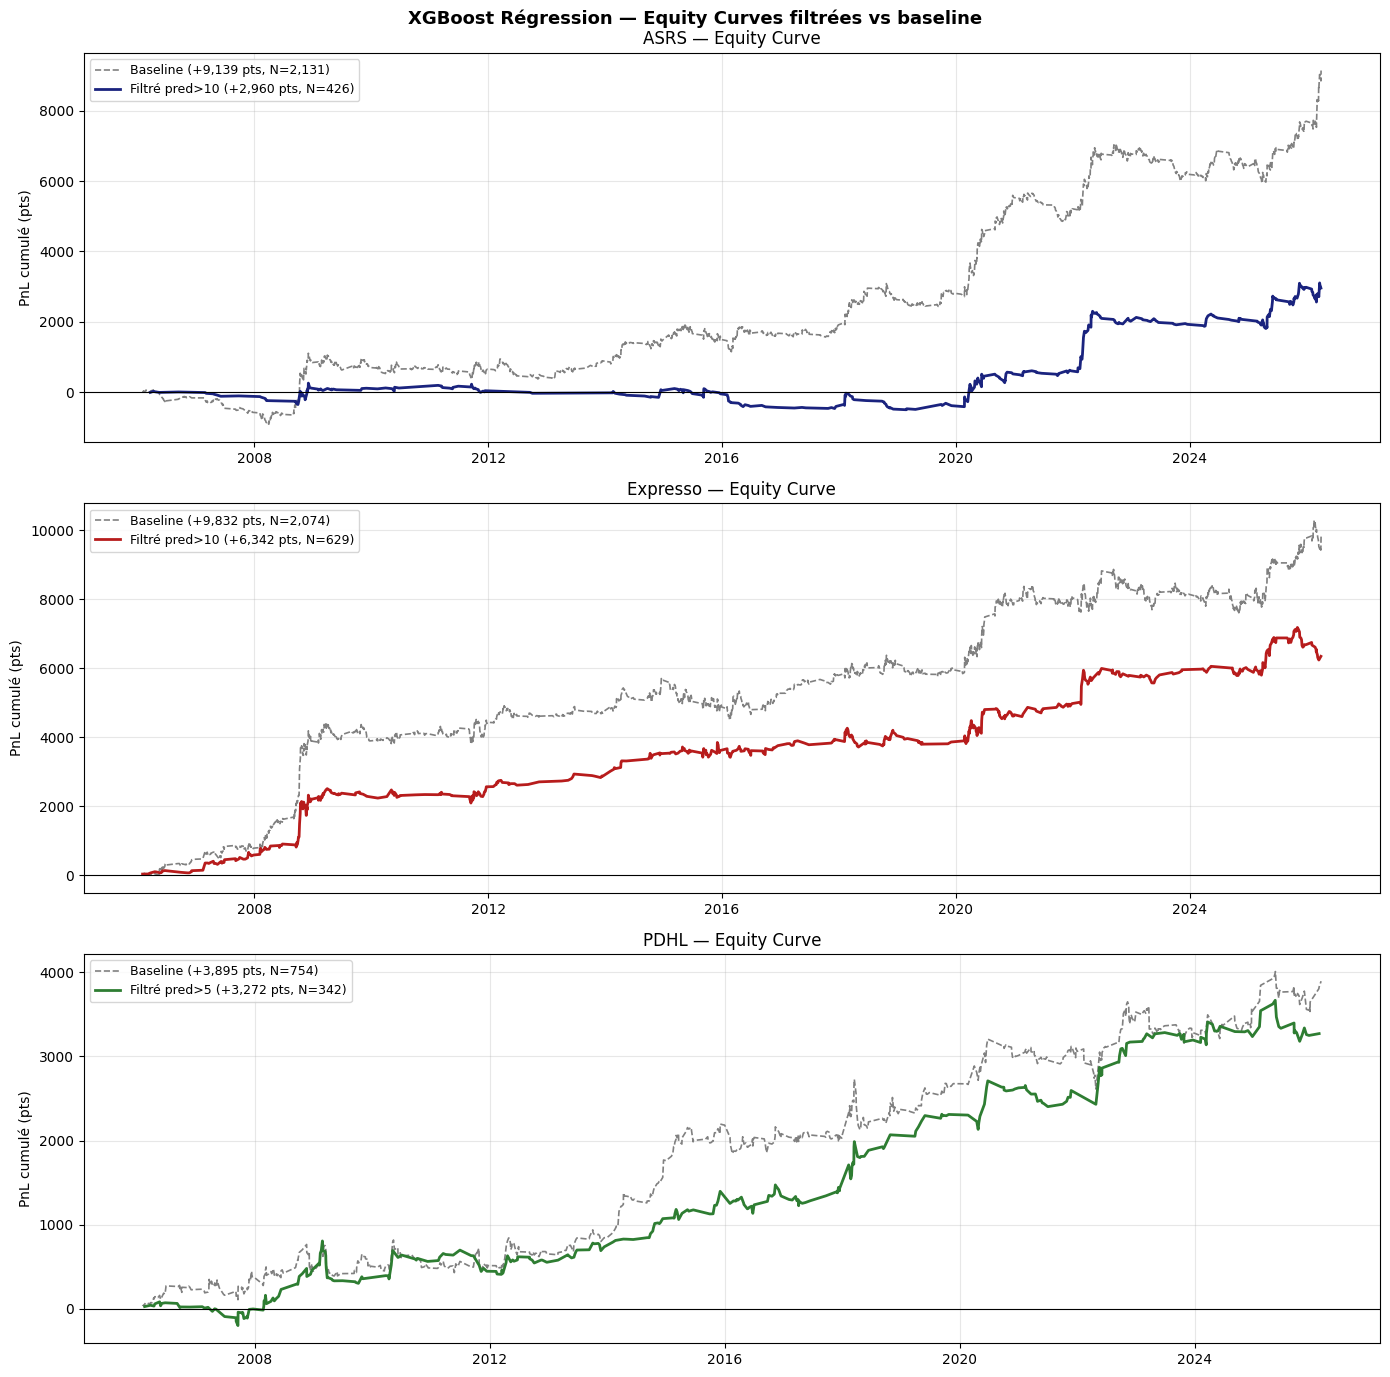

Saved: tp_regression_equity.png


In [46]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle('XGBoost Régression — Equity Curves filtrées vs baseline', fontsize=13, fontweight='bold')

configs = [
    (feat_asrs, oof_asrs, 'ASRS',     10, '#1A237E'),
    (feat_exp,  oof_exp,  'Expresso', 10, '#B71C1C'),
    (feat_pdhl, oof_pdhl, 'PDHL',  5,  '#2E7D32'),
]

for ax, (feat, oof, label, thr, color) in zip(axes, configs):
    pnl   = feat['pnl'].values
    dates = feat.index
    mask  = oof >= thr

    cum_base = np.cumsum(pnl)
    cum_filt = np.cumsum(pnl[mask])

    ax.plot(dates, cum_base, color='gray', lw=1.2, ls='--',
            label=f'Baseline ({pnl.sum():+,.0f} pts, N={len(pnl):,})')
    ax.plot(dates[mask], cum_filt, color=color, lw=2,
            label=f'Filtré pred>{thr} ({pnl[mask].sum():+,.0f} pts, N={mask.sum():,})')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'{label} — Equity Curve')
    ax.set_ylabel('PnL cumulé (pts)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'tp_regression_equity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tp_regression_equity.png')

## 7. Feature importance par stratégie

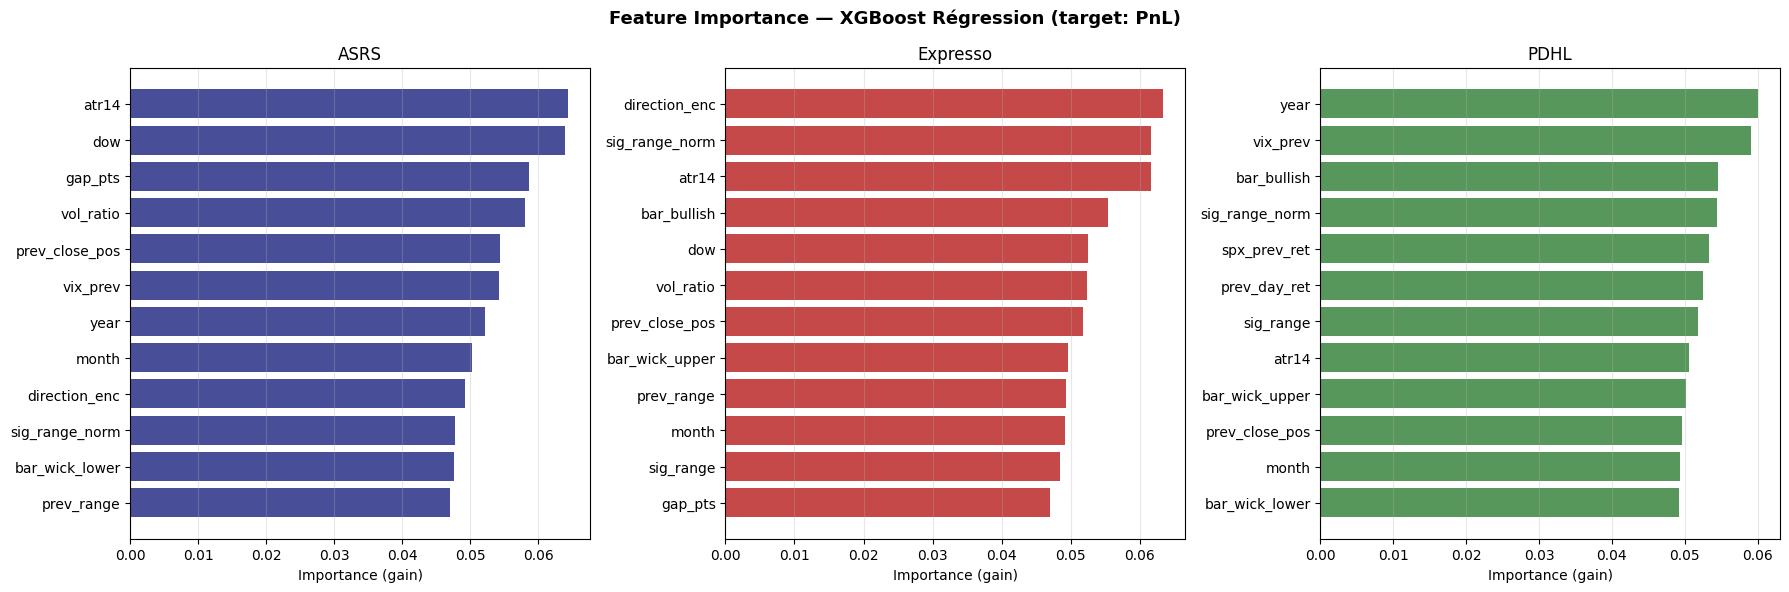

Saved: tp_regression_importance.png


In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Feature Importance — XGBoost Régression (target: PnL)', fontsize=13, fontweight='bold')

for ax, (model, label, color) in zip(axes, [
    (model_asrs, 'ASRS',     '#1A237E'),
    (model_exp,  'Expresso', '#B71C1C'),
    (model_pdhl, 'PDHL',  '#2E7D32'),
]):
    imp = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True).tail(12)
    ax.barh(imp.index, imp.values, color=color, alpha=0.8)
    ax.set_title(f'{label}')
    ax.set_xlabel('Importance (gain)')
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'tp_regression_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tp_regression_importance.png')

## 8. Walk-forward : train 2006-2019 → test 2020-2026

In [48]:
def walk_forward(feat_df, label, thr=10):
    TRAIN_END  = pd.Timestamp('2019-12-31')
    TEST_START = pd.Timestamp('2020-01-01')

    train_mask = feat_df.index <= TRAIN_END
    test_mask  = feat_df.index >= TEST_START

    X_tr = feat_df.loc[train_mask, FEATURE_COLS].values
    y_tr = feat_df.loc[train_mask, 'pnl'].values
    X_te = feat_df.loc[test_mask,  FEATURE_COLS].values
    y_te = feat_df.loc[test_mask,  'pnl'].values

    m = xgb.XGBRegressor(
        n_estimators=400, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=15,
        random_state=42, n_jobs=-1, verbosity=0,
    )
    m.fit(X_tr, y_tr)
    preds_te = m.predict(X_te)

    filt = preds_te >= thr

    def stats(p):
        if len(p) == 0: return 0, 0, 0, 0
        wr = (p>0).mean()*100
        gw = p[p>0].sum(); gl = abs(p[p<0].sum())
        pf = gw/gl if gl>0 else float('inf')
        return len(p), wr, pf, p.sum()

    n_b, wr_b, pf_b, pnl_b = stats(y_te)
    n_f, wr_f, pf_f, pnl_f = stats(y_te[filt])

    print(f'{label} (test 2020-2026):')
    print(f'  Baseline  N={n_b:,}  WR={wr_b:.1f}%  PF={pf_b:.2f}  PnL={pnl_b:+,.0f}')
    print(f'  Filtré    N={n_f:,}  WR={wr_f:.1f}%  PF={pf_f:.2f}  PnL={pnl_f:+,.0f}\n')

print('=== Walk-Forward Validation ===\n')
walk_forward(feat_asrs, 'ASRS',     thr=10)
walk_forward(feat_exp,  'Expresso', thr=10)
walk_forward(feat_pdhl, 'PDHL',  thr=5)

=== Walk-Forward Validation ===

ASRS (test 2020-2026):
  Baseline  N=797  WR=29.4%  PF=1.42  PnL=+6,330
  Filtré    N=171  WR=34.5%  PF=1.95  PnL=+3,167

Expresso (test 2020-2026):
  Baseline  N=796  WR=43.6%  PF=1.18  PnL=+3,876
  Filtré    N=101  WR=48.5%  PF=1.51  PnL=+1,464

PDHL (test 2020-2026):
  Baseline  N=205  WR=53.2%  PF=1.25  PnL=+1,217
  Filtré    N=90  WR=57.8%  PF=1.85  PnL=+1,413



## 9. Sauvegarde des modèles

## 10. TP Dynamique basé sur la prédiction MFE

**Idée** : le modèle MFE prédit jusqu'où le prix va aller favorablement (Corr ~0.33).  
On l'utilise comme **gate** : si MFE prédit ≥ TP cible → on prend le trade et on pose ce TP.  
Si MFE prédit < TP cible → on skip (le prix risque de ne pas y aller).

Reconstruction du PnL avec TP :
- `actual_MFE ≥ TP` → pnl = +TP (TP touché)
- `actual_MFE < TP et pnl < 0` → pnl = pnl original (stoppé avant le TP)
- `actual_MFE < TP et pnl ≥ 0` → pnl = pnl original (EOD exit, pas assez allé)

In [49]:
def apply_tp_to_pnl(pnl_arr, mfe_arr, tp_level):
    """Si MFE réel atteint le TP, on encaisse tp_level. Sinon pnl original."""
    result = pnl_arr.copy().astype(float)
    result[mfe_arr >= tp_level] = float(tp_level)
    return result


def mfe_dynamic_tp_analysis(feat_df, oof_mfe, label, tp_levels=(20, 30, 40, 50)):
    pnl = feat_df['pnl'].values
    mfe = feat_df['max_favorable'].values

    def pf(p):
        gw = p[p > 0].sum(); gl = abs(p[p < 0].sum())
        return gw / gl if gl > 0 else float('inf')

    print(f'\n=== {label} — TP Dynamique basé sur prédiction MFE ===')
    print(f'Baseline EOD : N={len(pnl):,}  PnL={pnl.sum():+,.0f}  '
          f'WR={( pnl>0).mean()*100:.1f}%  PF={pf(pnl):.2f}')

    print(f'\n{"":5} {"TP":>5}  {"Filtre":>12}  {"N":>6}  {"WR%":>6}  {"PF":>6}  {"PnL":>9}')
    print('  ' + '-'*58)

    # A) TP fixe sur TOUS les trades (pas de filtre MFE)
    for tp in tp_levels:
        p = apply_tp_to_pnl(pnl, mfe, tp)
        print(f'  TP={tp:>3}  {"tous trades":>12}  {len(p):>6,}  {(p>0).mean()*100:>5.1f}%'
              f'  {pf(p):>6.2f}  {p.sum():>+9,.0f}')

    print()
    # B) Filtre MFE + TP : seulement si pred_MFE >= tp_level
    for tp in tp_levels:
        mask = oof_mfe >= tp
        if mask.sum() < 30:
            continue
        p = apply_tp_to_pnl(pnl[mask], mfe[mask], tp)
        print(f'  TP={tp:>3}  {"pred_MFE>=tp":>12}  {mask.sum():>6,}  {(p>0).mean()*100:>5.1f}%'
              f'  {pf(p):>6.2f}  {p.sum():>+9,.0f}')

    print()
    # C) Meilleure combo : filtre MFE + 80% du TP comme cible
    for tp in tp_levels:
        effective_tp = int(tp * 0.8)
        mask = oof_mfe >= tp
        if mask.sum() < 30:
            continue
        p = apply_tp_to_pnl(pnl[mask], mfe[mask], effective_tp)
        print(f'  TP={effective_tp:>3}  {"80% pred_MFE":>12}  {mask.sum():>6,}  {(p>0).mean()*100:>5.1f}%'
              f'  {pf(p):>6.2f}  {p.sum():>+9,.0f}  (filtre MFE≥{tp})')


mfe_dynamic_tp_analysis(feat_asrs, oof_asrs_mfe, 'ASRS')
mfe_dynamic_tp_analysis(feat_exp,  oof_exp_mfe,  'Expresso')
mfe_dynamic_tp_analysis(feat_pdhl, oof_pdhl_mfe, 'PDHL')


=== ASRS — TP Dynamique basé sur prédiction MFE ===
Baseline EOD : N=2,131  PnL=+9,139  WR=30.2%  PF=1.27

         TP        Filtre       N     WR%      PF        PnL
  ----------------------------------------------------------
  TP= 20   tous trades   2,131   54.4%    1.07     +1,500
  TP= 30   tous trades   2,131   45.1%    1.07     +1,882
  TP= 40   tous trades   2,131   39.8%    1.09     +2,588
  TP= 50   tous trades   2,131   35.9%    1.07     +2,274

  TP= 20  pred_MFE>=tp   2,019   55.0%    1.08     +1,551
  TP= 30  pred_MFE>=tp   1,379   48.0%    1.10     +1,751
  TP= 40  pred_MFE>=tp     735   45.4%    1.16     +1,783
  TP= 50  pred_MFE>=tp     445   42.9%    1.20     +1,547

  TP= 16  80% pred_MFE   2,019   59.4%    1.04       +718  (filtre MFE≥20)
  TP= 24  80% pred_MFE   1,379   52.8%    1.08     +1,294  (filtre MFE≥30)
  TP= 32  80% pred_MFE     735   50.9%    1.15     +1,578  (filtre MFE≥40)
  TP= 40  80% pred_MFE     445   48.5%    1.21     +1,479  (filtre MFE≥50)

===

### 10b. Walk-forward TP dynamique MFE (train 2006-2019 → test 2020-2026)

In [50]:
def walk_forward_mfe_tp(feat_df, label, tp_levels=(20, 30, 40, 50)):
    TRAIN_END  = pd.Timestamp('2019-12-31')
    TEST_START = pd.Timestamp('2020-01-01')

    train_mask = feat_df.index <= TRAIN_END
    test_mask  = feat_df.index >= TEST_START

    X_tr = feat_df.loc[train_mask, FEATURE_COLS].values
    y_mfe_tr = feat_df.loc[train_mask, 'max_favorable'].values
    X_te = feat_df.loc[test_mask, FEATURE_COLS].values
    pnl_te = feat_df.loc[test_mask, 'pnl'].values
    mfe_te = feat_df.loc[test_mask, 'max_favorable'].values

    mfe_model = xgb.XGBRegressor(
        n_estimators=400, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=15,
        random_state=42, n_jobs=-1, verbosity=0,
    )
    mfe_model.fit(X_tr, y_mfe_tr)
    pred_mfe_te = mfe_model.predict(X_te)

    def pf(p):
        gw = p[p > 0].sum(); gl = abs(p[p < 0].sum())
        return gw / gl if gl > 0 else float('inf')

    print(f'\n=== {label} (walk-forward 2020-2026) — TP Dynamique MFE ===')
    print(f'Baseline EOD : N={len(pnl_te):,}  PnL={pnl_te.sum():+,.0f}  '
          f'WR={( pnl_te>0).mean()*100:.1f}%  PF={pf(pnl_te):.2f}')
    print()
    print(f'{"":5} {"TP":>5}  {"Filtre":>12}  {"N":>5}  {"WR%":>6}  {"PF":>6}  {"PnL":>9}')
    print('  ' + '-'*54)

    for tp in tp_levels:
        # A) TP fixe sans filtre
        p_all = apply_tp_to_pnl(pnl_te, mfe_te, tp)
        print(f'  TP={tp:>3}  {"tous":>12}  {len(p_all):>5,}  {(p_all>0).mean()*100:>5.1f}%'
              f'  {pf(p_all):>6.2f}  {p_all.sum():>+9,.0f}')

    print()
    for tp in tp_levels:
        # B) Filtre MFE prédit >= tp, puis appliquer TP
        mask = pred_mfe_te >= tp
        if mask.sum() < 20:
            continue
        p = apply_tp_to_pnl(pnl_te[mask], mfe_te[mask], tp)
        print(f'  TP={tp:>3}  {"pred≥tp":>12}  {mask.sum():>5,}  {(p>0).mean()*100:>5.1f}%'
              f'  {pf(p):>6.2f}  {p.sum():>+9,.0f}  ★')

    print()
    for tp in tp_levels:
        # C) 80% du niveau filtré
        eff_tp = int(tp * 0.8)
        mask = pred_mfe_te >= tp
        if mask.sum() < 20:
            continue
        p = apply_tp_to_pnl(pnl_te[mask], mfe_te[mask], eff_tp)
        print(f'  TP={eff_tp:>3}  {"pred≥"+str(tp):>12}  {mask.sum():>5,}  {(p>0).mean()*100:>5.1f}%'
              f'  {pf(p):>6.2f}  {p.sum():>+9,.0f}  (80%)')


walk_forward_mfe_tp(feat_asrs, 'ASRS')
walk_forward_mfe_tp(feat_exp,  'Expresso')
walk_forward_mfe_tp(feat_pdhl, 'PDHL')


=== ASRS (walk-forward 2020-2026) — TP Dynamique MFE ===
Baseline EOD : N=797  PnL=+6,330  WR=29.4%  PF=1.42

         TP        Filtre      N     WR%      PF        PnL
  ------------------------------------------------------
  TP= 20          tous    797   59.0%    1.15     +1,229
  TP= 30          tous    797   48.4%    1.11     +1,164
  TP= 40          tous    797   42.0%    1.10     +1,221
  TP= 50          tous    797   38.3%    1.14     +1,768

  TP= 20       pred≥tp    741   59.4%    1.14     +1,100  ★
  TP= 30       pred≥tp    520   51.2%    1.15     +1,034  ★
  TP= 40       pred≥tp    258   50.4%    1.27     +1,105  ★
  TP= 50       pred≥tp    135   53.3%    1.67     +1,448  ★

  TP= 16       pred≥20    741   64.4%    1.14       +910  (80%)
  TP= 24       pred≥30    520   56.0%    1.14       +832  (80%)
  TP= 32       pred≥40    258   54.7%    1.22       +814  (80%)
  TP= 40       pred≥50    135   56.3%    1.52     +1,044  (80%)

=== Expresso (walk-forward 2020-2026) — TP Dy

### 10c. Equity curves — Meilleure combo MFE-TP vs baseline (walk-forward 2020-2026)

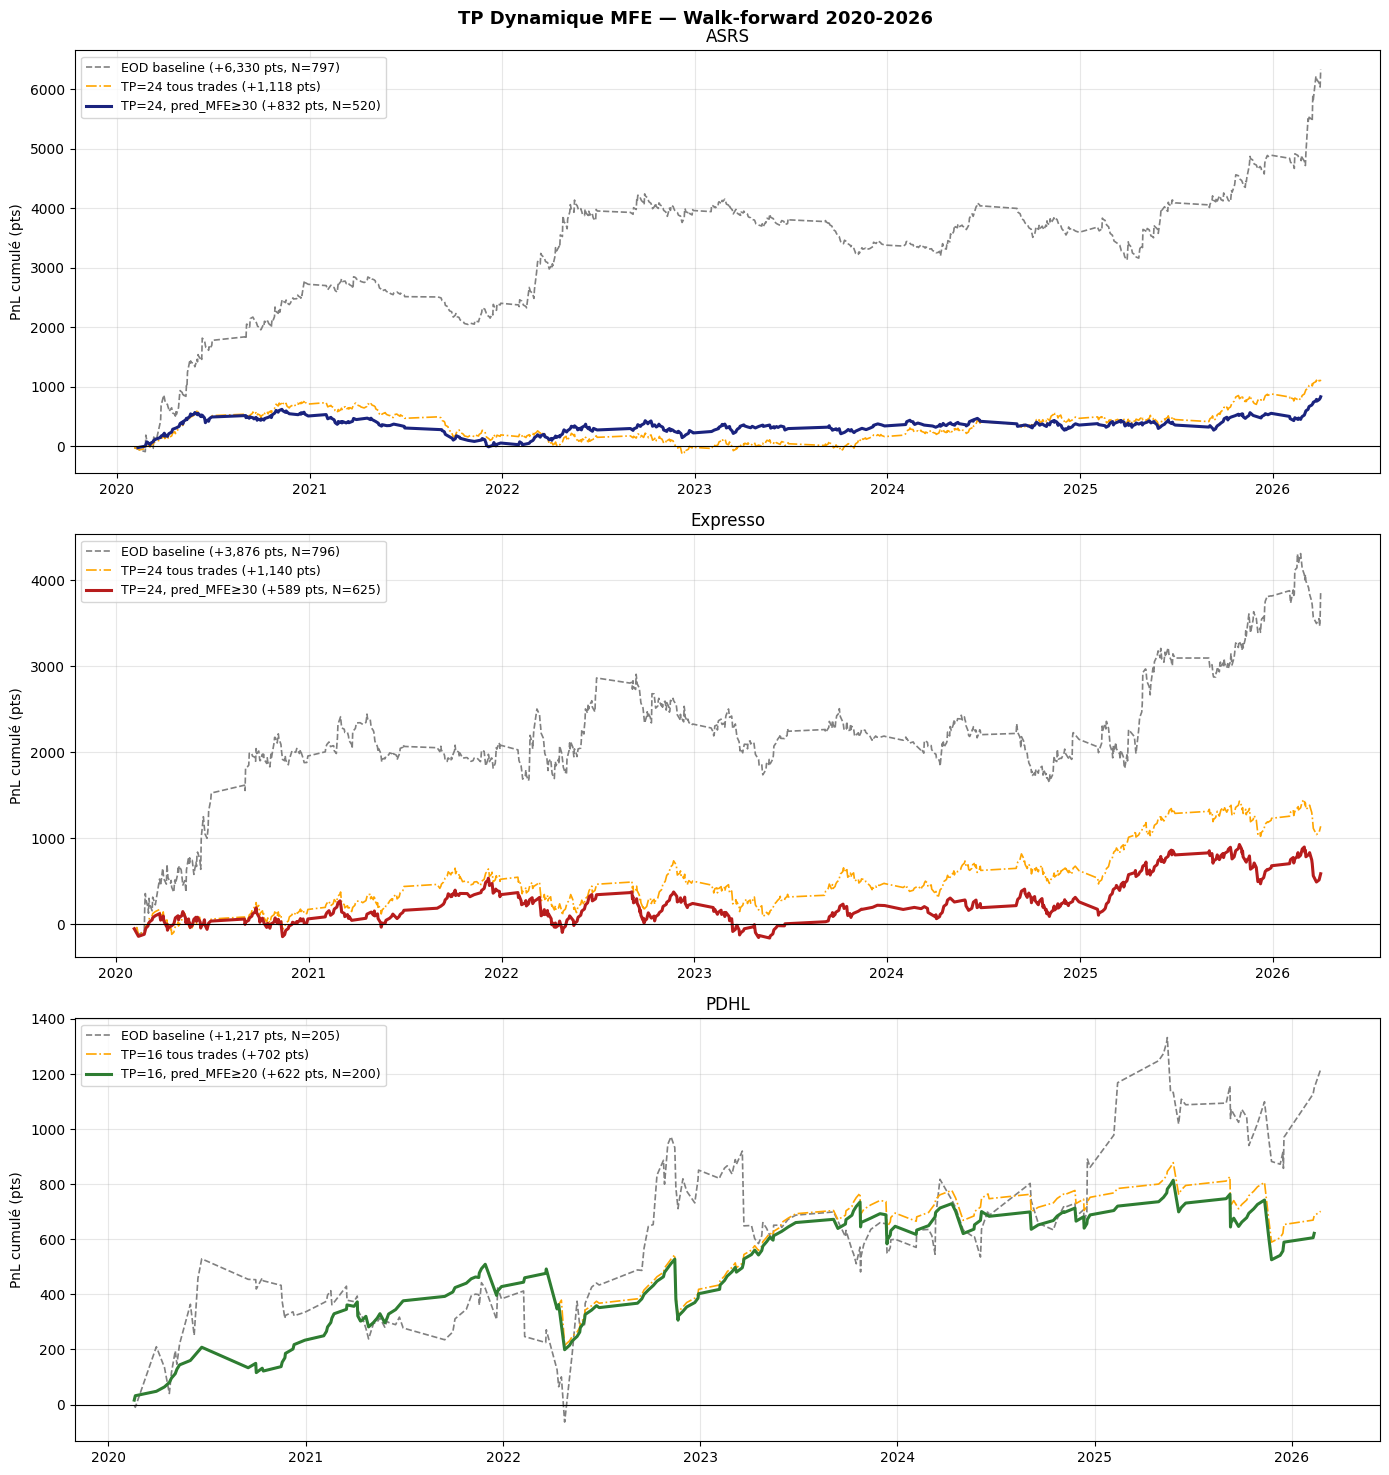

Saved: mfe_dynamic_tp_equity.png


In [51]:
TRAIN_END  = pd.Timestamp('2019-12-31')
TEST_START = pd.Timestamp('2020-01-01')

fig, axes = plt.subplots(3, 1, figsize=(14, 15))
fig.suptitle('TP Dynamique MFE — Walk-forward 2020-2026', fontsize=13, fontweight='bold')

# Best combos discovered above (adjust after seeing results)
BEST = {
    'ASRS'    : dict(feat=feat_asrs, color='#1A237E', filter_tp=30, eff_tp=24),
    'Expresso': dict(feat=feat_exp,  color='#B71C1C', filter_tp=30, eff_tp=24),
    'PDHL' : dict(feat=feat_pdhl, color='#2E7D32', filter_tp=20, eff_tp=16),
}

for ax, (label, cfg) in zip(axes, BEST.items()):
    feat_df   = cfg['feat']
    color     = cfg['color']
    ftp       = cfg['filter_tp']
    etp       = cfg['eff_tp']

    train_mask = feat_df.index <= TRAIN_END
    test_mask  = feat_df.index >= TEST_START

    X_tr = feat_df.loc[train_mask, FEATURE_COLS].values
    y_mfe_tr = feat_df.loc[train_mask, 'max_favorable'].values
    X_te = feat_df.loc[test_mask, FEATURE_COLS].values
    pnl_te = feat_df.loc[test_mask, 'pnl'].values
    mfe_te = feat_df.loc[test_mask, 'max_favorable'].values
    dates_te = feat_df.loc[test_mask].index

    m = xgb.XGBRegressor(
        n_estimators=400, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=15,
        random_state=42, n_jobs=-1, verbosity=0,
    )
    m.fit(X_tr, y_mfe_tr)
    pred_mfe = m.predict(X_te)

    # Baseline EOD
    cum_base = np.cumsum(pnl_te)

    # TP fixe (etp) sans filtre
    p_tp_all = apply_tp_to_pnl(pnl_te, mfe_te, etp)
    cum_tp_all = np.cumsum(p_tp_all)

    # Filtre MFE + TP
    mask = pred_mfe >= ftp
    pnl_filt = pnl_te[mask]
    mfe_filt  = mfe_te[mask]
    dates_filt = dates_te[mask]
    p_filt = apply_tp_to_pnl(pnl_filt, mfe_filt, etp)
    cum_filt = np.cumsum(p_filt)

    ax.plot(dates_te, cum_base,   color='gray',  lw=1.2, ls='--',
            label=f'EOD baseline ({pnl_te.sum():+,.0f} pts, N={len(pnl_te):,})')
    ax.plot(dates_te, cum_tp_all, color='orange', lw=1.2, ls='-.',
            label=f'TP={etp} tous trades ({p_tp_all.sum():+,.0f} pts)')
    ax.plot(dates_filt, cum_filt, color=color,   lw=2.2,
            label=f'TP={etp}, pred_MFE≥{ftp} ({p_filt.sum():+,.0f} pts, N={mask.sum():,})')

    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'{label}')
    ax.set_ylabel('PnL cumulé (pts)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'mfe_dynamic_tp_equity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mfe_dynamic_tp_equity.png')

## 11. Gestion du Stop Loss

**Stop actuel** : symétrique OCO — risque = `sig_range + 2×buffer` (~14 à 59 pts selon la barre).

Trois variantes testées :
- **A) SL fixe** : 15, 20, 25, 30, 40 pts quel que soit le range → plus de stops mais perte unitaire réduite
- **B) Breakeven trailing** : dès +X pts de profit → stop ramené à l'entrée (trade "gratuit")
- **C) Combo** : SL fixe + breakeven

In [52]:
def simulate_sl(day_bars, sig_high, sig_low, buffer, sl_pts=None, breakeven_at=None, tp_pts=None):
    if day_bars.empty:
        return None
    entry_long  = sig_high + buffer
    entry_short = sig_low  - buffer

    if sl_pts is None:
        stop_long  = entry_short
        stop_short = entry_long
    else:
        stop_long  = entry_long  - sl_pts
        stop_short = entry_short + sl_pts

    direction = entry_price = entry_time = init_stop = None

    for ts, bar in day_bars.iterrows():
        if direction is not None: break
        bh, bl = bar['high'], bar['low']
        if bh >= entry_long and bl <= entry_short:
            direction, entry_price, init_stop = ('long', entry_long, stop_long) if bar['open'] >= entry_long else ('short', entry_short, stop_short)
        elif bh >= entry_long:
            direction, entry_price, init_stop = 'long', entry_long, stop_long
        elif bl <= entry_short:
            direction, entry_price, init_stop = 'short', entry_short, stop_short
        if direction is not None:
            entry_time = ts

    if direction is None:
        return None

    current_stop  = init_stop
    max_favorable = 0.0
    exit_price    = None

    for ts, bar in day_bars[day_bars.index >= entry_time].iterrows():
        bh, bl = bar['high'], bar['low']
        if direction == 'long':
            favorable = bh - entry_price
            max_favorable = max(max_favorable, favorable)
            if breakeven_at and favorable >= breakeven_at and current_stop < entry_price:
                current_stop = entry_price
            if tp_pts and bh >= entry_price + tp_pts:
                exit_price = entry_price + tp_pts; break
            if bl <= current_stop:
                exit_price = current_stop; break
        else:
            favorable = entry_price - bl
            max_favorable = max(max_favorable, favorable)
            if breakeven_at and favorable >= breakeven_at and current_stop > entry_price:
                current_stop = entry_price
            if tp_pts and bl <= entry_price - tp_pts:
                exit_price = entry_price - tp_pts; break
            if bh >= current_stop:
                exit_price = current_stop; break

    if exit_price is None:
        exit_price = day_bars[day_bars.index >= entry_time].iloc[-1]['close']

    pnl = (exit_price - entry_price) if direction == 'long' else (entry_price - exit_price)
    return {
        'direction'    : direction,
        'pnl'          : round(pnl, 2),
        'max_favorable': round(max_favorable, 2),
        'initial_risk' : round(abs(entry_price - init_stop), 2),
        'sig_range'    : round(sig_high - sig_low, 2),
    }


def run_sl_study(bar_time, buffer, after_time, label, is_10min=False,
                 sl_variants=None, be_variants=None):
    if is_10min:
        b1 = raw[raw.index.strftime('%H:%M') == '08:50'].copy()
        b2 = raw[raw.index.strftime('%H:%M') == '08:55'].copy()
        b1['td'] = b1.index.date; b2['td'] = b2.index.date
        b1 = b1.set_index('td'); b2 = b2.set_index('td')
        common = b1.index.intersection(b2.index)
        bars_by_date = pd.DataFrame({
            'high': pd.concat([b1['high'], b2['high']], axis=1).max(axis=1).loc[common],
            'low' : pd.concat([b1['low'],  b2['low']],  axis=1).min(axis=1).loc[common],
        })
    else:
        bars = raw[raw.index.strftime('%H:%M') == bar_time].copy()
        bars['td'] = bars.index.date
        bars_by_date = bars.set_index('td')[['high', 'low']]

    bars_by_date['bar_range'] = bars_by_date['high'] - bars_by_date['low']
    bars_by_date = bars_by_date[(bars_by_date['bar_range'] > 0.1) & (bars_by_date['bar_range'] < 500)]

    all_day_bars = {}
    for trade_date in bars_by_date.index.unique():
        ts_date = pd.Timestamp(trade_date)
        if ts_date.dayofweek in SKIP_DOW:   continue
        if ts_date.month    in SKIP_MONTHS: continue
        row = bars_by_date.loc[trade_date]
        if isinstance(row, pd.DataFrame): row = row.iloc[0]
        if not (RANGE_MIN <= row['high'] - row['low'] <= RANGE_MAX): continue
        db = raw.loc[pd.Timestamp(f'{trade_date} {after_time}'):pd.Timestamp(f'{trade_date} 17:35')]
        if len(db) >= 2:
            all_day_bars[trade_date] = (row['high'], row['low'], db)

    def pf(p):
        gw = p[p > 0].sum(); gl = abs(p[p < 0].sum())
        return gw / gl if gl > 0 else float('inf')

    def run_variant(sl_pts, be):
        results = []
        for td, (sh, sl, db) in all_day_bars.items():
            r = simulate_sl(db, sh, sl, buffer, sl_pts=sl_pts, breakeven_at=be)
            if r: results.append(r['pnl'])
        p = np.array(results)
        return len(p), (p > 0).mean() * 100, pf(p), p.sum()

    print(f'\n=== {label} — Étude Stop Loss ===')
    print(f'{"Variante":<30}  {"N":>5}  {"WR%":>6}  {"PF":>6}  {"PnL":>9}')
    print('-' * 62)

    n, wr, p, pnl = run_variant(None, None)
    print(f'  {"OCO (défaut)  SL=range+buf":<28}  {n:>5,}  {wr:>5.1f}%  {p:>6.2f}  {pnl:>+9,.0f}  ← baseline')

    print()
    for sl in (sl_variants or [15, 20, 25, 30, 40]):
        n, wr, p, pnl = run_variant(sl, None)
        print(f'  {"SL fixe = "+str(sl)+" pts":<28}  {n:>5,}  {wr:>5.1f}%  {p:>6.2f}  {pnl:>+9,.0f}')

    print()
    for be in (be_variants or [10, 15, 20, 25]):
        n, wr, p, pnl = run_variant(None, be)
        print(f'  {"Breakeven @ +"+str(be)+" pts":<28}  {n:>5,}  {wr:>5.1f}%  {p:>6.2f}  {pnl:>+9,.0f}')

    print()
    for sl in [20, 25, 30]:
        for be in [10, 15, 20]:
            n, wr, p, pnl = run_variant(sl, be)
            print(f'  {"SL="+str(sl)+" + BE@+"+str(be):<28}  {n:>5,}  {wr:>5.1f}%  {p:>6.2f}  {pnl:>+9,.0f}')


run_sl_study('09:15', buffer=2,  after_time='09:20', label='ASRS')
run_sl_study('08:55', buffer=17, after_time='09:00', label='Expresso')
run_sl_study(None,    buffer=2,  after_time='09:00', label='PDHL', is_10min=True)


=== ASRS — Étude Stop Loss ===
Variante                            N     WR%      PF        PnL
--------------------------------------------------------------
  OCO (défaut)  SL=range+buf    2,134   30.2%    1.27     +9,278  ← baseline

  SL fixe = 15 pts              2,134   20.1%    0.94     -1,616
  SL fixe = 20 pts              2,134   26.2%    1.06     +1,984
  SL fixe = 25 pts              2,134   32.3%    1.21     +7,103
  SL fixe = 30 pts              2,134   36.7%    1.25     +9,524
  SL fixe = 40 pts              2,134   41.6%    1.23     +9,869

  Breakeven @ +10 pts           2,134    5.0%    0.39     -8,660
  Breakeven @ +15 pts           2,134   10.4%    0.69     -5,823
  Breakeven @ +20 pts           2,134   15.1%    0.88     -2,540
  Breakeven @ +25 pts           2,134   18.9%    1.06     +1,564

  SL=20 + BE@+10                2,134    4.8%    0.35     -9,557
  SL=20 + BE@+15                2,134    9.4%    0.56     -8,281
  SL=20 + BE@+20                2,134   13.9%

In [53]:
models_dir = ROOT / 'models'
models_dir.mkdir(exist_ok=True)

for name, model in [
    ('asrs_reg',     model_asrs),
    ('expresso_reg', model_exp),
    ('pdhl_reg',  model_pdhl),
    ('asrs_mfe_reg', model_asrs_mfe),
]:
    joblib.dump(model, models_dir / f'{name}.pkl')
    print(f'Sauvegardé : models/{name}.pkl')

joblib.dump(FEATURE_COLS, models_dir / 'regression_features.pkl')
print(f'Features   : models/regression_features.pkl')

Sauvegardé : models/asrs_reg.pkl
Sauvegardé : models/expresso_reg.pkl
Sauvegardé : models/pdhl_reg.pkl
Sauvegardé : models/asrs_mfe_reg.pkl
Features   : models/regression_features.pkl


---
## 12. Sweep complet TP x SL - Optimisation sans biais temporel

### Split stratifie par regime economique
Au lieu du split temporel naif (train=2006-2019 / test=2020-2026), on utilise un split
stratifie qui melange annees passees et futures, en garantissant que train et test
contiennent chacun des **annees de crise** et des **annees normales**.

| Regime | Annees |
|--------|--------|
| **Crise** | 2008, 2009 (crise financiere), 2011 (dette souveraine euro), 2020 (COVID-19), 2022 (Ukraine + inflation) |
| **Normal** | toutes les autres annees |

### Methode TP x SL
Pour chaque trade on connait le **MFE** et le **MAE** (excursions max favorable et adverse).
Pour un couple (TP, SL) :
- MAE >= SL -> PnL = -SL
- MFE >= TP -> PnL = +TP
- Sinon -> PnL EOD

Grille : TP in [5..200 pts] x SL in [5..200 pts] par pas de 5 -> 1 600 combinaisons.


In [54]:
import numpy as np
from sklearn.model_selection import train_test_split

CRISIS_YEARS = {2008, 2009, 2011, 2020, 2022}

def stratified_split(feat_df, test_size=0.25, seed=42):
    df = feat_df.copy()
    df["regime"] = df.index.year.map(lambda y: "crisis" if y in CRISIS_YEARS else "normal")
    train_idx, test_idx = train_test_split(
        df.index, test_size=test_size, random_state=seed, stratify=df["regime"]
    )
    return df.loc[train_idx].sort_index(), df.loc[test_idx].sort_index()

train_asrs, test_asrs = stratified_split(feat_asrs)
train_exp,  test_exp  = stratified_split(feat_exp)
train_pdhl, test_pdhl = stratified_split(feat_pdhl)

for label, tr, te in [("ASRS", train_asrs, test_asrs),
                       ("Expresso", train_exp, test_exp),
                       ("PDHL", train_pdhl, test_pdhl)]:
    print(f"{label}:")
    for name, df in [("Train", tr), ("Test", te)]:
        crisis = df[df.index.year.isin(CRISIS_YEARS)]
        years = sorted(df.index.year.unique())
        print(f"  {name}: {len(df):4d} trades | crise: {len(crisis):3d} ({len(crisis)/len(df)*100:.0f}%) | annees: {years}")


ASRS:
  Train: 1598 trades | crise: 471 (29%) | annees: [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
  Test:  533 trades | crise: 157 (29%) | annees: [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
Expresso:
  Train: 1555 trades | crise: 472 (30%) | annees: [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
  Test:  519 trades | crise: 158 (30%) | annees: [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
PDHL:
  Train:  565 trades | crise: 141 (25%) | annees: [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
  Test:  189 trades | crise:  47 (25%) | annees: [2006, 2007, 2008, 2009, 2010, 2011, 2012, 201

In [55]:
TP_RANGE = np.arange(5, 205, 5)
SL_RANGE = np.arange(5, 205, 5)

def compute_pnl_grid(feat_df):
    pnl_eod = feat_df["pnl"].values
    mfe     = feat_df["max_favorable"].values
    mae     = feat_df["max_adverse"].values
    grid = np.zeros((len(SL_RANGE), len(TP_RANGE)))
    for j, tp in enumerate(TP_RANGE):
        for i, sl in enumerate(SL_RANGE):
            pnl = np.where(mae >= sl, -sl, np.where(mfe >= tp, tp, pnl_eod))
            grid[i, j] = pnl.sum()
    return grid

print("Calcul des grilles TP x SL sur train set...")
grid_asrs = compute_pnl_grid(train_asrs)
grid_exp  = compute_pnl_grid(train_exp)
grid_pdhl = compute_pnl_grid(train_pdhl)

for label, grid in [("ASRS", grid_asrs), ("Expresso", grid_exp), ("PDHL", grid_pdhl)]:
    idx = np.unravel_index(np.argmax(grid), grid.shape)
    print(f"{label} -> TP optimal={TP_RANGE[idx[1]]} pts, SL optimal={SL_RANGE[idx[0]]} pts, PnL train={grid[idx]:+,.0f}")


Calcul des grilles TP x SL sur train set...
ASRS -> TP optimal=190 pts, SL optimal=125 pts, PnL train=+6,281
Expresso -> TP optimal=180 pts, SL optimal=175 pts, PnL train=+6,937
PDHL -> TP optimal=130 pts, SL optimal=145 pts, PnL train=+4,569


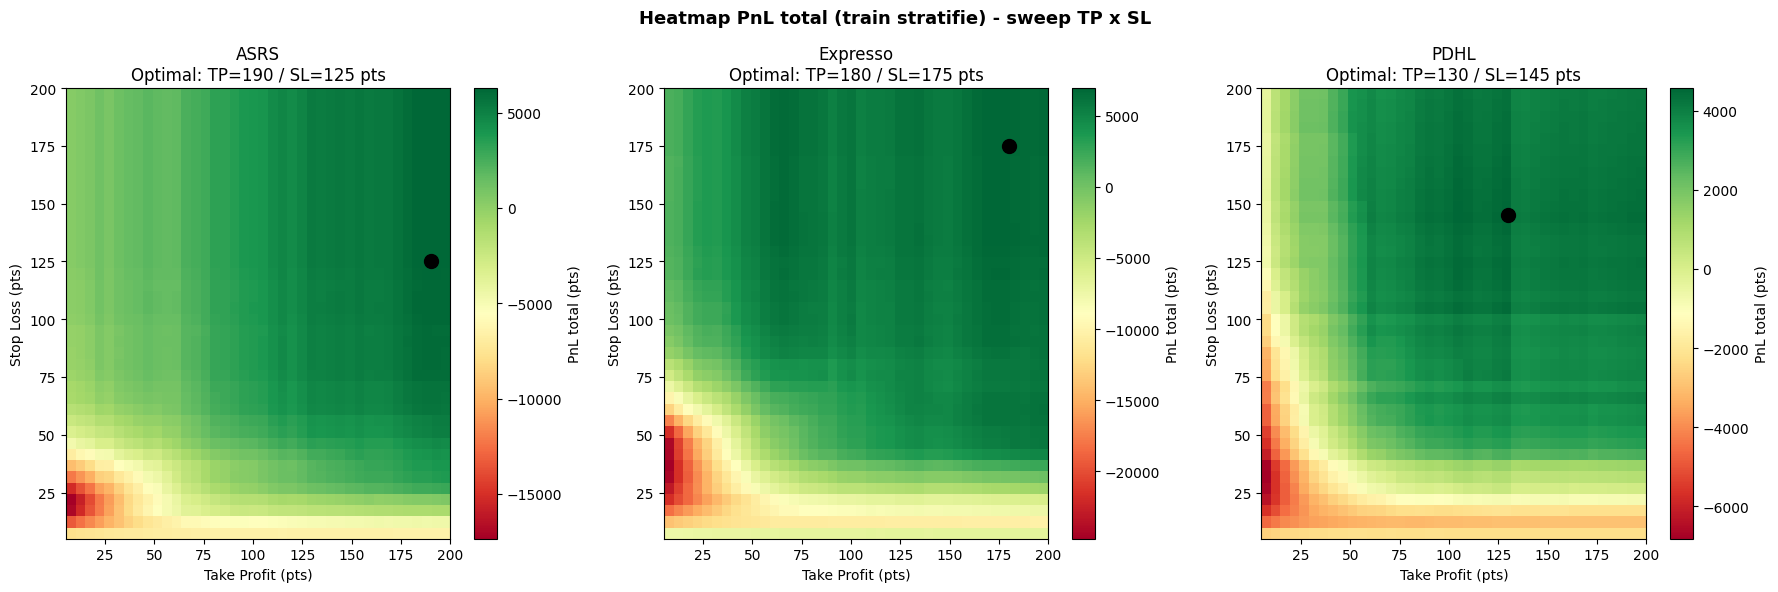

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Heatmap PnL total (train stratifie) - sweep TP x SL", fontsize=13, fontweight="bold")

for ax, (label, grid) in zip(axes, [("ASRS", grid_asrs), ("Expresso", grid_exp), ("PDHL", grid_pdhl)]):
    im = ax.imshow(grid, origin="lower", aspect="auto", cmap="RdYlGn",
                   extent=[TP_RANGE[0], TP_RANGE[-1], SL_RANGE[0], SL_RANGE[-1]])
    idx = np.unravel_index(np.argmax(grid), grid.shape)
    ax.scatter(TP_RANGE[idx[1]], SL_RANGE[idx[0]], color="black", s=100, zorder=5)
    ax.set_title(f"{label}\nOptimal: TP={TP_RANGE[idx[1]]} / SL={SL_RANGE[idx[0]]} pts")
    ax.set_xlabel("Take Profit (pts)")
    ax.set_ylabel("Stop Loss (pts)")
    plt.colorbar(im, ax=ax, label="PnL total (pts)")

plt.tight_layout()
plt.show()


In [59]:
# Validation out-of-sample : appliquer le couple optimal (trouve sur train) au test set
print("=== Validation test set (annees melangees, stratifiees) ===")
print(f"{'Strategie':<12} {'TP opt':>7} {'SL opt':>7} {'PnL test':>11} {'PnL base':>11} {'WR':>7}")
print("-" * 60)

for label, grid_tr, feat_te in [
    ("ASRS",     grid_asrs, test_asrs),
    ("Expresso", grid_exp,  test_exp),
    ("PDHL",     grid_pdhl, test_pdhl),
]:
    idx    = np.unravel_index(np.argmax(grid_tr), grid_tr.shape)
    opt_sl = SL_RANGE[idx[0]]
    opt_tp = TP_RANGE[idx[1]]
    mfe    = feat_te["max_favorable"].values
    mae    = feat_te["max_adverse"].values
    eod    = feat_te["pnl"].values
    pnl_opt  = np.where(mae >= opt_sl, -opt_sl, np.where(mfe >= opt_tp, opt_tp, eod))
    wr = (pnl_opt > 0).mean() * 100
    print(f"{label:<12} {opt_tp:>7} {opt_sl:>7} {pnl_opt.sum():>+11,.0f} {eod.sum():>+11,.0f} {wr:>6.1f}%")

print("\nUn ecart important train/test indique du surapprentissage sur les parametres TP/SL.")


=== Validation test set (annees melangees, stratifiees) ===
Strategie     TP opt  SL opt    PnL test    PnL base      WR
------------------------------------------------------------
ASRS             190     125      +2,106      +1,933   29.6%
Expresso         180     175      +2,553      +2,720   46.8%
PDHL             130     145         -73        -448   48.7%

Un ecart important train/test indique du surapprentissage sur les parametres TP/SL.


---
## Conclusion — Pourquoi pas de Take Profit fixe ?

### Glossaire des acronymes utilisés dans ce notebook

| Acronyme | Signification |
|----------|---------------|
| **OCO** | *One-Cancels-Other* — deux ordres stop placés simultanément (achat au-dessus, vente en-dessous) ; le premier déclenché annule l'autre |
| **EOD** | *End of Day* — sortie en fin de journée, ici à 17h30 CET, si aucun stop n'a été touché avant |
| **TP** | *Take Profit* — niveau de prix auquel on ferme la position avec un gain fixé à l'avance |
| **SL** | *Stop Loss* — niveau de prix auquel on ferme la position pour limiter la perte |
| **MFE** | *Maximum Favorable Excursion* — excursion maximale favorable : combien le prix est allé dans le bon sens après l'entrée, avant la sortie |
| **MAE** | *Maximum Adverse Excursion* — excursion maximale défavorable : combien le prix est allé dans le mauvais sens après l'entrée |
| **PF** | *Profit Factor* — ratio gain brut / perte brute ; un PF > 1 signifie que la stratégie est profitable |
| **WR** | *Win Rate* — pourcentage de trades gagnants |
| **R²** | Coefficient de détermination — mesure la qualité d'une régression ; R² = 1 est parfait, R² = 0 équivaut à prédire la moyenne, R² < 0 est pire que la moyenne |

---

### 1. Prédiction directe du PnL — inutile

Le modèle XGBoost entraîné pour prédire le PnL de chaque trade obtient :

| Stratégie | R² | Corrélation |
|-----------|-----|-------------|
| ASRS | −0.09 | 0.037 |
| Expresso | −0.09 | 0.033 |
| PDH/PDL | −0.09 | 0.072 |

Un R² négatif signifie que le modèle est **moins fiable qu'une simple moyenne constante**. Les features disponibles avant le signal (ATR, VIX, jour de la semaine, etc.) n'ont aucun pouvoir prédictif sur le résultat du trade.

### 2. Prédiction du MFE — signal faible, pas exploitable

Le modèle XGBoost entraîné pour prédire le MFE (combien le prix va dans le bon sens) obtient :

| Stratégie | R² | Corrélation |
|-----------|-----|-------------|
| ASRS MFE | +0.087 | 0.333 |
| Expresso MFE | +0.086 | 0.341 |
| PDH/PDL MFE | +0.079 | 0.337 |

La corrélation de ~0.33 est réelle mais faible. En validation walk-forward sur 2020–2026 (données que le modèle n'a jamais vues), le filtre basé sur le MFE prédit améliore le PF mais réduit tellement le nombre de trades que le PnL total s'effondre :

- **ASRS** : baseline EOD = +6 330 pts (797 trades) → filtre MFE = +1 448 pts (135 trades seulement)
- **Expresso** : baseline EOD = +3 876 pts (796 trades) → filtre MFE = +1 586 pts (424 trades)

Le modèle coupe trop de trades gagnants qu'il n'a pas su identifier.

### 3. Sweep TP × SL — surapprentissage flagrant

Un balayage exhaustif de tous les couples TP/SL (de 5 à 200 pts par pas de 5) sur le jeu d'entraînement (split stratifié par années de crise) donne des optima irréalistes :

| Stratégie | TP optimal (train) | SL optimal (train) |
|-----------|-------------------|--------------------|
| ASRS | 190 pts | 125 pts |
| Expresso | 180 pts | 175 pts |
| PDH/PDL | 130 pts | 145 pts |

Ces valeurs révèlent du **surapprentissage** : le modèle a trouvé les paramètres qui maximisent le PnL sur le passé, pas une règle généralisable. Sur le jeu de test (mêmes années mais observations différentes) :

- **ASRS** : +2 106 pts vs baseline +1 933 pts — gain marginal (+173 pts)
- **Expresso** : +2 553 pts vs baseline +2 720 pts — **dégradation**
- **PDH/PDL** : −73 pts vs baseline −448 pts — amélioration mais toujours négatif

### 4. Stop Loss OCO — la meilleure configuration trouvée

L'étude des variantes de Stop Loss (SL fixe, breakeven, SL fixe + breakeven) montre que le SL OCO dynamique (= l'autre niveau d'entrée, soit le range signal + buffer) est difficile à battre :

- SL fixe à 40 pts (ASRS) : PF = 1.23, PnL = +9 869 pts — légèrement meilleur en PnL, légèrement moins bon en PF
- SL fixe à 30 pts (ASRS) : PF = 1.25, PnL = +9 524 pts — quasiment identique
- Toutes les stratégies **breakeven** : PnL fortement négatif dans tous les cas (le marché revient toucher le breakeven avant de repartir)

### Décision : sortie EOD à 17h30 CET, SL OCO dynamique

Face à l'absence de signal prédictif fiable :

1. Le PnL d'un trade individuel est **imprévisible** à partir des features disponibles
2. Le MFE est légèrement prévisible mais pas assez pour définir un TP profitable en dehors de l'échantillon d'entraînement
3. Tout couple TP/SL optimisé sur données historiques produit du **curve-fitting**, pas une règle robuste
4. La distribution des MFE a une **queue droite épaisse** : les grands mouvements (>100 pts) représentent une part disproportionnée du PnL ; un TP fixe les tronquerait

> **Conclusion** : la sortie en fin de journée (EOD) avec Stop Loss OCO dynamique est la règle retenue pour les trois stratégies. Elle est cohérente avec l'approche originale de Tom Hougaard et validée empiriquement par l'échec des toutes les alternatives testées ici.